# Task 01：多臂老虎机——学习与实验入口

## 本 Notebook 的学习边界

本任务先解释隐藏的真实价值，再通过 `src/` 中的 Greedy、ε-greedy、UCB 和 Beta-Bernoulli Thompson Sampling 观察探索与利用。真实价值记为：

$$
q_*(a)=\mathbb{E}[R_t\mid A_t=a].
$$

Notebook 不复制算法实现；代码单元只负责导入、最小验证和实验。`Q(a)` 是 Agent 的估计，`R_t` 是一次有噪声的采样，二者不能混为一谈。

学习顺序：先运行环境/更新示例，再运行单轨迹，最后运行多次独立实验并解释平均奖励和最优动作率。


# Task 01：从零理解多臂老虎机

本 Notebook 只做三件事：看懂环境与动作接口、用最小例子检查更新、做一个简单的策略对比。算法实现放在 `src/`，这里不重复实现。

学习目标：理解真实奖励与估计价值的区别，并观察探索如何帮助发现高价值动作。

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
TASK_DIR = next((p.resolve() for p in candidates if (p / "src" / "treasure_bandit.py").is_file()), None)
assert TASK_DIR is not None, "请从 task-01-bandit 或其 notebooks 目录启动 Notebook"
if str(TASK_DIR) not in sys.path:
    sys.path.insert(0, str(TASK_DIR))

from src import EpsilonGreedyAgent, GreedyAgent, ThompsonSamplingAgent, TreasureHuntBandit, UCBAgent

print("task directory:", TASK_DIR)

task directory: /workspace/YiFan/llm_agent/repos/RL-beginner/task-01-bandit


## 1. 环境：真实价值与一次采样

每个动作都有一个隐藏的宝物发现概率。Agent 只能通过 `step(action)` 观察 0/1 奖励；实验者才知道真实概率。

In [2]:
treasure_probs = np.array([0.15, 0.30, 0.60, 0.85])
env = TreasureHuntBandit(treasure_probs, seed=42)

samples = [env.step(3) for _ in range(10)]
print("一次采样结果:", samples)
print("真实最优动作:", env.optimal_action)
print("最优动作真实价值:", env.optimal_value)
assert all(reward in (0.0, 1.0) for reward in samples)

一次采样结果: [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0]
真实最优动作: 3
最优动作真实价值: 0.85


## 2. 最小更新：Q 值如何从奖励中学习

下面让纯 Greedy 观察一个固定环境。`Q` 是 Agent 的估计，不等于环境中的真实概率；`N` 记录每个动作被选择的次数。

In [3]:
env = TreasureHuntBandit([0.2, 0.8], seed=7)
agent = GreedyAgent(n_actions=2, seed=7)

for _ in range(12):
    action = agent.select_action()
    reward = env.step(action)
    agent.update(action, reward)

print("动作访问次数 N:", agent.N)
print("估计价值 Q:", np.round(agent.Q, 3))
assert int(agent.N.sum()) == 12

动作访问次数 N: [ 0 12]
估计价值 Q: [0.   0.75]


## 3. 简单实验：探索策略对比

用相同的宝物概率和步数比较四种策略。曲线是单次轨迹的累计平均奖励，只用于直观看趋势；正式结论应使用多次独立实验。

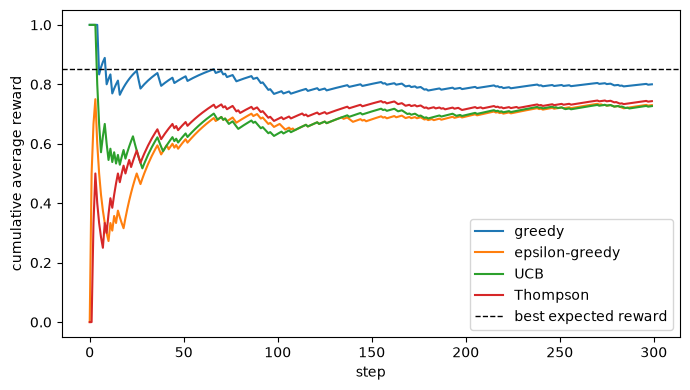

In [4]:
def run_agent(agent_factory, seed=0, n_steps=300):
    env = TreasureHuntBandit(treasure_probs, seed=seed)
    agent = agent_factory(seed)
    rewards = []
    for _ in range(n_steps):
        action = agent.select_action()
        reward = env.step(action)
        agent.update(action, reward)
        rewards.append(reward)
    rewards = np.asarray(rewards, dtype=float)
    return np.cumsum(rewards) / np.arange(1, n_steps + 1)

factories = {
    "greedy": lambda seed: GreedyAgent(4, seed=seed),
    "epsilon-greedy": lambda seed: EpsilonGreedyAgent(4, epsilon=0.1, seed=seed),
    "UCB": lambda seed: UCBAgent(4, c=1.0, seed=seed),
    "Thompson": lambda seed: ThompsonSamplingAgent(4, seed=seed),
}

plt.figure(figsize=(7, 4))
for name, factory in factories.items():
    plt.plot(run_agent(factory), label=name)
plt.axhline(treasure_probs.max(), color="black", linestyle="--", linewidth=1, label="best expected reward")
plt.xlabel("step")
plt.ylabel("cumulative average reward")
plt.legend()
plt.tight_layout()
plt.show()

## 4. 边界检查

本任务的 Thompson Sampling 是 Beta-Bernoulli 版本，只接受 0/1 奖励；连续奖励不能直接传入。

In [5]:
agent = ThompsonSamplingAgent(n_actions=2, seed=0)
agent.update(0, 1.0)
agent.update(0, 0.0)
print("posterior means:", np.round(agent.Q, 3))

try:
    agent.update(0, 0.5)
except ValueError as exc:
    print("连续奖励被正确拒绝:", exc)
else:
    raise AssertionError("Beta-Bernoulli Thompson Sampling 应拒绝连续奖励")

posterior means: [0.5 0.5]
连续奖励被正确拒绝: Thompson Sampling requires Bernoulli rewards 0 or 1


## 实验结论与提交要求

运行完本 Notebook 后，不要只保留图。请在对应 `notes/` 中记录随机种子、环境版本、关键超参数、最终指标、曲线文件和一个失败现象。结论必须区分“代码运行成功”和“算法表现更好”：前者由自检确认，后者需要多 seed 或控制变量实验支持。

提交前从仓库根目录运行：

```bash
python eval/run.py
```
